generate synthetic data by using the beginning token from the training data for a model

run the model autoregressively, try a few different temperatures T for sampling

In [ ]:
%load_ext autoreload

In [2]:
%autoreload 2
import os
import glob
import numpy as np
import torch
import torch.nn.functional as F
import webdataset as wds
from tqdm.auto import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

from umt.evals.eval_utils import load_model_from_checkpoint

/scratch/gpfs/WBIALEK/ls1546/.conda/envs/gpt-circuits/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The code length of a sequence $x_1, \dots, x_T$ under the model is
$$\ell(x) = -\sum_{t=1}^{T} \log_2 p(x_t \mid x_1, \dots, x_{t-1})$$
where $p$ is the model's softmax distribution at temperature $T{=}1$.

**Pass 1 — generation.** We sample each token from the temperature-adjusted distribution
$q_T(x_t \mid \cdot) \propto p(x_t \mid \cdot)^{1/T}$. Temperature controls diversity,
not the model's actual beliefs.

**Pass 2 — evaluation.** We feed the completed sequence back through the model
(forward pass with targets) to obtain the *true* log-probabilities $\log p(x_t \mid \cdot)$
and compute $\ell(x)$.

At $T{=}1$ the expected per-token code length equals the model's entropy.
At $T{<}1$ (deterministic) code lengths should be *lower*; at $T{>}1$ (random) they
should be *higher*. Comparing against real-text genres tells us which temperature
regime each genre lives in.


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b", use_fast=True)

Device: cuda


In [4]:
# --- paths ---
base_dir = '/scratch/gpfs/WBIALEK/ls1546/llms-entropy'
data_base = '/scratch/gpfs/WBIALEK/ls1546/DCLM/rust_processing/tokshuf-rs'
ckpt_base = os.path.join('/scratch/gpfs/WBIALEK/ls1546/gpt-circuits', 'out')
save_dir = os.path.join(base_dir, 'synth_data')
fig_dir = os.path.join(base_dir, 'figures')
os.makedirs(save_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# --- model arch (matches training configs) ---
n_layer = 24
n_head = 16
n_embd = 2048
block_size = 2048
bias = False
dropout = 0.0
z_loss = 1e-4

# --- eval settings ---
eval_shard = 1          
batch_size = 1          # sequences per forward pass (tune to fit GPU memory)
max_sequences = 1    # None = all sequences in the shard; set to small int for quick tests

### Data loading

Each `.tar` shard contains samples where `json.gz` is a list of 2049 token IDs.
Split into `x = tokens[:-1]` (input, length 2048) and `y = tokens[1:]` (target, length 2048).

In [5]:
import itertools

def preprocess_xs(sample):
    """WebDataset sample -> first token as a priming id."""
    tokens = torch.tensor(sample['json.gz'], dtype=torch.long)
    return tokens[:1]   # (1,)

def build_dataloader(shard_num, batch_size, max_sequences=None):
    shard_dir = os.path.join(data_base, f'dclm_tokshuf_{shard_num}')
    urls = sorted(glob.glob(os.path.join(shard_dir, '*.tar')))
    print(f"Found {len(urls)} tar files in shard {shard_num}")

    dataset = (
        wds.WebDataset(urls, resampled=False, shardshuffle=False, empty_check=False)
        .decode()
        .map(preprocess_xs)
    )

    if max_sequences is not None:
        samples = list(itertools.islice(dataset, max_sequences))
        dataset = torch.utils.data.TensorDataset(torch.stack(samples))
        print(f"Materialized {len(samples)} priming tokens")

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=8,
        pin_memory=True,
    )
    return loader


In [6]:
def load_model(run_name, ckpt_num):
    ckpt_path = os.path.join(ckpt_base, run_name, f'{run_name}_ckpt_{ckpt_num}.pt')
    checkpoint = torch.load(ckpt_path, map_location=device)
    model = load_model_from_checkpoint(
        checkpoint, n_layer, n_head, n_embd, block_size, bias, dropout, z_loss, device
    )
    model.eval()
    return model

does autoregressive generation match the codelength results from actual data?

test on 1 token from training data (shard 1)

compute codelength as function of context length, sample at different T and plot all on same figure

also plot some histograms of the distribution at each position

### generate autoregressively for each "priming" token for a specific T

In [7]:
@torch.no_grad()
def generate_from_priming_token(model, loader, temperature):
    """
    Generate full-length sequences from single priming tokens.

    Returns:
        synth_ids: (N, block_size) int64 array of generated token ids
    """
    all_synth = []
    max_new_tokens = block_size - 1

    for (x,) in tqdm(loader, desc=f"generating T={temperature}"):
        priming_tokens = x.to(device)    # (B, 1)
        generated = model.generate(priming_tokens, max_new_tokens, temperature=temperature)
        all_synth.append(generated.cpu().numpy())

    return np.concatenate(all_synth, axis=0)


In [8]:
test_run = 'shard1_m1337_d1337'
test_ckpt = 47000

model = load_model(test_run, test_ckpt)
print(f"Loaded {test_run} ckpt {test_ckpt}")

number of parameters: 1713.78M
Loaded shard1_m1337_d1337 ckpt 47000


### compute code length on generated sequences

Feed the generated token IDs back through the model as a standard forward pass
(with targets) to get the true log-probabilities at each position.


In [9]:
@torch.no_grad()
def calc_codelength_from_ids(model, token_ids, batch_size=4):
    """
    Compute per-position code lengths for pre-tokenized sequences.

    Args:
        model:     GPT model in eval mode
        token_ids: (N, seq_len) numpy array or tensor of token ids
        batch_size: forward-pass batch size

    Returns:
        avg_codelen:   scalar, average code length in bits/token
        pos_avg:       (seq_len-1,) numpy array, per-position average code length
        all_codelen:   (N, seq_len-1) numpy array, per-token code lengths
    """
    if isinstance(token_ids, np.ndarray):
        token_ids = torch.from_numpy(token_ids).long()

    N, S = token_ids.shape
    pos_sum = torch.zeros(S - 1)
    pos_count = torch.zeros(S - 1)
    all_codelen = []

    for start in tqdm(range(0, N, batch_size), desc="codelength eval"):
        ids = token_ids[start : start + batch_size].to(device)  # (B, S)
        inp = ids[:, :-1].contiguous()       # (B, S-1)
        tgt = ids[:, 1:].contiguous()        # (B, S-1)

        logits, _ = model(inp, tgt)          # (B, S-1, V)
        log_probs = F.log_softmax(logits, dim=-1)  # numerically stable

        # gather the log-prob assigned to each actual next token
        token_log_probs = log_probs.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)  # (B, S-1)
        codelen = -token_log_probs / np.log(2)  # nats -> bits

        all_codelen.append(codelen.cpu())
        T = codelen.shape[1]
        pos_sum[:T] += codelen.sum(dim=0).cpu()
        pos_count[:T] += codelen.shape[0]

    all_codelen = torch.cat(all_codelen, dim=0).numpy()  # (N, S-1)
    pos_avg = (pos_sum / pos_count.clamp_min(1)).numpy()
    avg_codelen = all_codelen.mean()

    return avg_codelen, pos_avg, all_codelen


### Pass 1: generate synthetic corpora at multiple temperatures


In [10]:
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5]


In [ ]:

loader = build_dataloader(eval_shard, batch_size, max_sequences=max_sequences)

for T in temperatures:
    out_path = os.path.join(save_dir, f'synth_ids_T{T}.npy')
    if os.path.exists(out_path):
        print(f'T={T}: already exists at {out_path}, skipping')
        continue

    print(f"\nGenerating T={T} ...")
    synth_ids = generate_from_priming_token(model, loader, temperature=T)
    np.save(out_path, synth_ids)
    print(f"  Saved {synth_ids.shape} to {out_path}")


### Inspect: decode a few generated sequences at each temperature

In [11]:
n_examples = 2
max_chars = 500

for T in temperatures:
    id_path = os.path.join(save_dir, f'synth_ids_T{T}.npy')
    if not os.path.exists(id_path):
        print(f'T={T}: {id_path} not found, skipping')
        continue

    synth_ids = np.load(id_path)
    print(f"\nT={T}: loaded {synth_ids.shape} from disk")
    print(f"\n{'='*60}")
    print(f"T = {T}")
    print(f"{'='*60}")
    for i in range(min(n_examples, synth_ids.shape[0])):
        text = tokenizer.decode(synth_ids[i])
        print(f"\n--- Sequence {i} ---")
        print(text[:max_chars])
        print('...')



T=0.5: loaded (1, 2048) from disk

T = 0.5

--- Sequence 0 ---
 loans are available for use in a variety of ways.

For example, some lenders offer home equity loans to help borrowers pay off their mortgages. Others offer loans to help individuals pay for new appliances or home improvements. Still others offer loans for business expansion.

How Are Home Equity Loans Paid Off?

Home equity loans are paid off in a variety of ways. Some lenders offer payment plans that allow borrowers to pay back their loans in several monthly installments. Others offer borrowe
...

T=0.8: loaded (1, 2048) from disk

T = 0.8

--- Sequence 0 ---
 loans went through the roof, but not because of the Dream Act.

It would take some time, but eventually, the economy will recover. It may be a while before the unemployment rate drops, but a lot of this is temporary, and the economy will eventually recover in another year or two.

When it comes to immigration, we can’t turn the clock back.  We’ve made progress bas

### Pass 2: load saved IDs and compute code lengths


In [12]:
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5]

results = {}

for T in temperatures:
    id_path = os.path.join(save_dir, f'synth_ids_T{T}.npy')
    if not os.path.exists(id_path):
        print(f'T={T}: {id_path} not found, skipping')
        continue

    synth_ids = np.load(id_path)
    print(f"\nT={T}: loaded {synth_ids.shape} from disk")

    avg_cl, pos_avg, all_cl = calc_codelength_from_ids(model, synth_ids,
                                                       batch_size=batch_size)
    print(f"  Avg code length: {avg_cl:.4f} bits/token")

    results[T] = {
        'avg_codelen': avg_cl,
        'pos_avg': pos_avg,
        'all_codelen': all_cl,
        'synth_ids': synth_ids,
    }

    np.savez(os.path.join(save_dir, f'synth_codelen_T{T}.npz'),
             pos_avg=pos_avg, all_codelen=all_cl)



T=0.5: loaded (1, 2048) from disk


codelength eval: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.17s/it]


  Avg code length: 0.5317 bits/token

T=0.8: loaded (1, 2048) from disk


codelength eval: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.40it/s]


  Avg code length: 2.4465 bits/token

T=1.0: loaded (1, 2048) from disk


...

  Avg code length: 5.9805 bits/token

T=1.2: loaded (1, 2048) from disk


codelength eval: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.40it/s]


  Avg code length: 13.2926 bits/token

T=1.5: loaded (1, 2048) from disk


codelength eval: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.41it/s]

  Avg code length: 14.7367 bits/token


### Plot: code length vs position for each temperature


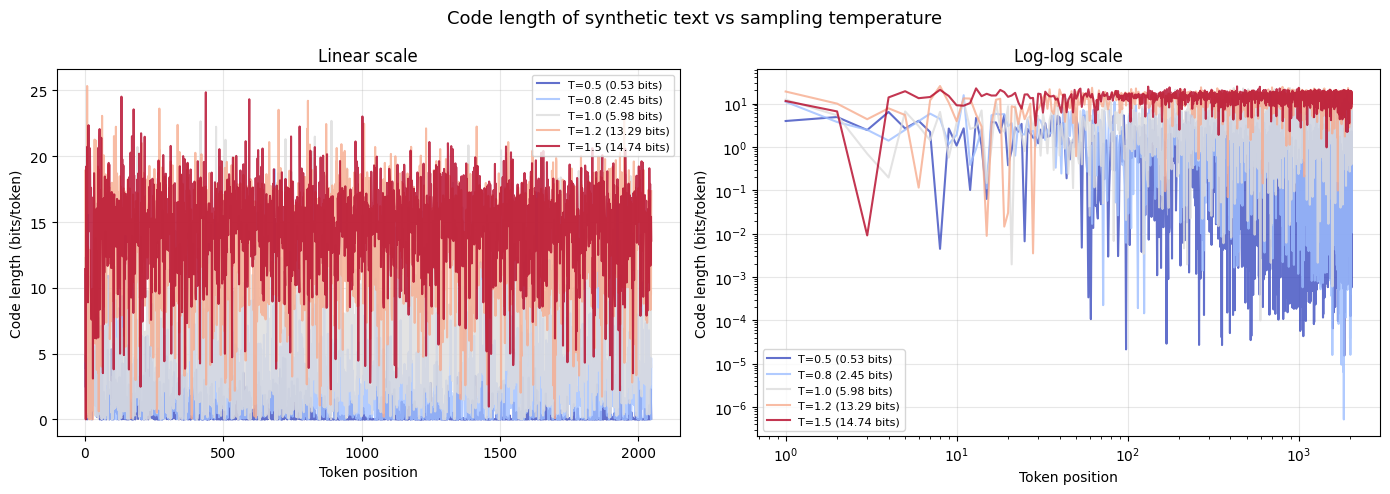

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = plt.cm.coolwarm
T_vals = sorted(results.keys())
norm = plt.Normalize(vmin=min(T_vals), vmax=max(T_vals))

for T in T_vals:
    pos_avg = results[T]['pos_avg']
    positions = np.arange(1, len(pos_avg) + 1)
    color = cmap(norm(T))
    label = f'T={T} ({results[T]["avg_codelen"]:.2f} bits)'

    axes[0].plot(positions, pos_avg, color=color, alpha=0.8, label=label)
    axes[1].plot(positions, pos_avg, color=color, alpha=0.8, label=label)

axes[0].set_xlabel('Token position')
axes[0].set_ylabel('Code length (bits/token)')
axes[0].set_title('Linear scale')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Token position')
axes[1].set_ylabel('Code length (bits/token)')
axes[1].set_title('Log-log scale')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Code length of synthetic text vs sampling temperature', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'synth_codelen_vs_temperature.pdf'), bbox_inches='tight')
plt.show()


### Summary: average code length at each temperature


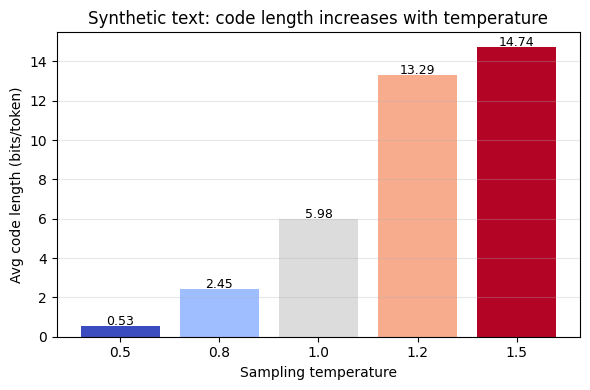

In [14]:
T_vals = sorted(results.keys())
avg_cls = [results[T]['avg_codelen'] for T in T_vals]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([str(T) for T in T_vals], avg_cls, color=[cmap(norm(T)) for T in T_vals])
ax.set_xlabel('Sampling temperature')
ax.set_ylabel('Avg code length (bits/token)')
ax.set_title('Synthetic text: code length increases with temperature')
for bar, val in zip(bars, avg_cls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'synth_avg_codelen_bar.pdf'), bbox_inches='tight')
plt.show()


### Histograms: per-token code length distributions at selected positions


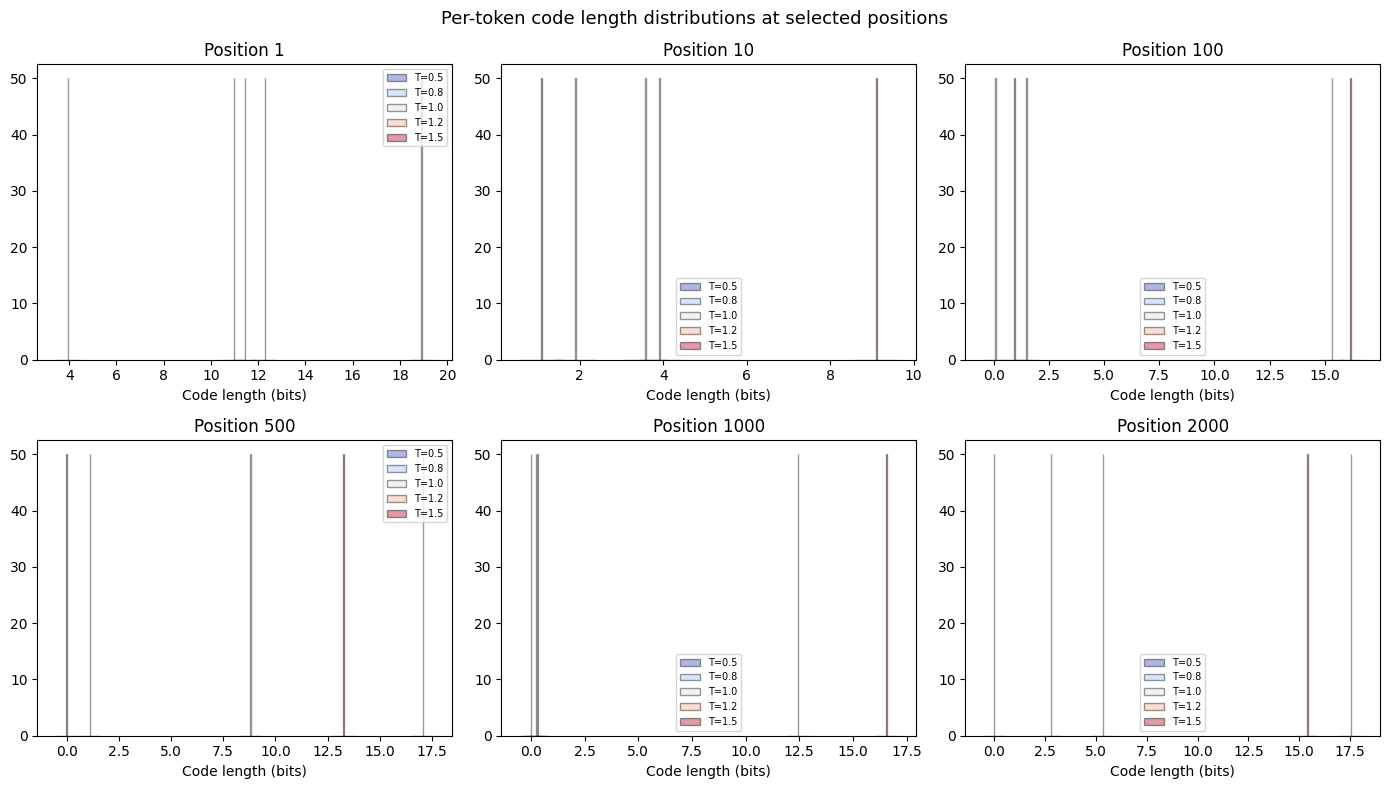

In [16]:
positions_to_plot = [1, 10, 100, 500, 1000, 2000]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, pos in zip(axes, positions_to_plot):
    idx = pos - 1  # 0-indexed into (N, S-1) codelength array
    for T in sorted(results.keys()):
        cl = results[T]['all_codelen']
        if idx < cl.shape[1]:
            ax.hist(cl[:, idx], bins=50, alpha=0.4, density=True,
                    color=cmap(norm(T)), label=f'T={T}', edgecolor='black')
    ax.set_title(f'Position {pos}')
    ax.set_xlabel('Code length (bits)')
    ax.legend(fontsize=7)

fig.suptitle('Per-token code length distributions at selected positions', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'synth_codelen_histograms.pdf'), bbox_inches='tight')
plt.show()


### Inspect: decode a few generated sequences at each temperature


In [ ]:
n_examples = 2
max_chars = 500


for T in sorted(results.keys()):
    print(f"\n{'='*60}")
    print(f"T = {T}")
    print(f"{'='*60}")
    for i in range(min(n_examples, results[T]['synth_ids'].shape[0])):
        text = tokenizer.decode(results[T]['synth_ids'][i])
        print(f"\n--- Sequence {i} ---")
        print(text[:max_chars])
        print('...')
